In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
# from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import time

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv('./dataset_VMD_short_normal.csv')

df.tail()

,case_id,segment_index,label,bis,mode1_sample_entropy,mode1_spectral_entropy,mode1_skewness,mode1_kurtosis,mode2_sample_entropy,mode2_spectral_entropy,mode2_skewness,mode2_kurtosis,mode3_sample_entropy,mode3_spectral_entropy,mode3_skewness,mode3_kurtosis
31186,case9.mat,1188,0,61.0,0.539,0.569,-1.101,3.928,0.999,0.652,0.015,0.186,1.312,0.701,-0.009,-0.201
31187,case9.mat,1189,0,62.0,0.496,0.524,1.145,3.418,1.130,0.676,0.014,-0.485,1.174,0.680,-0.007,-0.077
31188,case9.mat,1190,0,63.0,0.648,0.551,-0.266,2.887,0.836,0.637,-0.005,0.468,1.145,0.686,-0.018,0.927
31189,case9.mat,1191,0,63.0,0.675,0.658,1.249,1.877,1.262,0.717,0.018,-0.035,1.112,0.674,-0.021,-0.231
31190,case9.mat,1192,0,63.0,0.324,0.416,0.947,2.291,0.896,0.730,0.063,0.969,0.649,0.651,0.028,1.329


In [3]:
X = df.drop(columns=['label', 'segment_index', 'bis', 'case_id'])
y = df['label']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Sebelum SMOTE:")
print(y_train.value_counts())

print("Sesudah SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Sebelum SMOTE:
label
0    23422
1     1530
Name: count, dtype: int64
Sesudah SMOTE:
label
0    23422
1    23422
Name: count, dtype: int64


In [5]:
clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        class_weight='balanced'
    ),
    random_state=42,
    n_estimators=50
)

pipe = make_pipeline(
    StandardScaler(),
    clf
)

pipe.fit(X_train_resampled, y_train_resampled)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('baggingclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ht='balanced')
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",50
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0


In [6]:
from sklearn.utils import resample

# gabungkan dulu
test_df = X_test.copy()
test_df["label"] = y_test.values if hasattr(y_test, "values") else y_test

# pisahkan kelas
df_tidak_sadar = test_df[test_df["label"] == 0]
df_sadar = test_df[test_df["label"] == 1]

# ambil jumlah minimum
n_min = min(len(df_tidak_sadar), len(df_sadar))

# undersampling kelas mayoritas
df_tidak_sadar_bal = resample(
    df_tidak_sadar,
    replace=False,
    n_samples=n_min,
    random_state=42
)

df_sadar_bal = resample(
    df_sadar,
    replace=False,
    n_samples=n_min,
    random_state=42
)

# gabungkan dan acak
test_balanced = pd.concat([df_tidak_sadar_bal, df_sadar_bal]).sample(frac=1, random_state=42).reset_index(drop=True)

X_test_bal = test_balanced.drop(columns=["label"])
y_test_bal = test_balanced["label"]

print(y_test_bal.value_counts())

label
1    383
0    383
Name: count, dtype: int64


In [7]:
y_prob = pipe.predict_proba(X_test_bal)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
# y_pred = pipe.predict(X_test)
print(accuracy_score(y_test_bal, y_pred))
print(precision_score(y_test_bal, y_pred, average='binary'))
print(f1_score(y_test_bal, y_pred, average='binary'))
print(recall_score(y_test_bal, y_pred, average='binary'))

0.9216710182767625
0.9523809523809523
0.918918918918919
0.8877284595300261


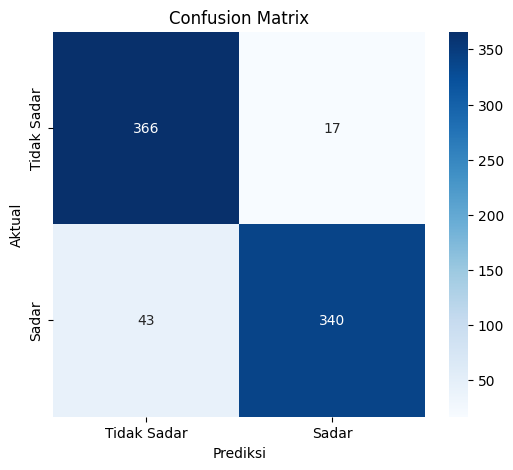

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_bal, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Tidak Sadar', 'Sadar'],
            yticklabels=['Tidak Sadar', 'Sadar'])

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

In [9]:
y_prob = pipe.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
# y_pred = pipe.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred, average='binary'))
print(f1_score(y_test, y_pred, average='binary'))
print(recall_score(y_test, y_pred, average='binary'))

0.9615322968424427
0.633147113594041
0.7391304347826086
0.8877284595300261


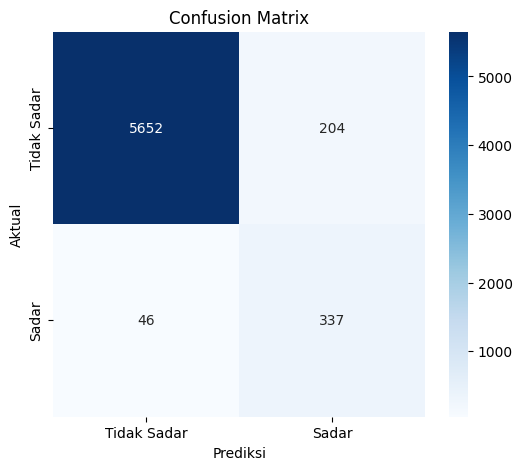

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Tidak Sadar', 'Sadar'],
            yticklabels=['Tidak Sadar', 'Sadar'])

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

In [10]:
import joblib

joblib.dump(pipe, "model_VMD_filter_normal.pkl")

['model_VMD_filter_normal.pkl']